# Mesh Contraction & Skeleton Refinement Ablation Study

This notebook evaluates the performance, distance error metrics, and structural refinement impact of 7 skeleton extraction and post-processing algorithms on variable-radius 3D tube meshes:

1. **Base Au et al. (Raw Contraction)**
2. **Full Au et al. (Refined Pipeline)**
3. **Au et al. + 1 Pass Taubin Smoothing**
4. **Au et al. + 2 Passes Taubin Smoothing**
5. **Algo A (`subdivide_and_center_skeleton`, `max_edge_len=0.4`)**
6. **Algo B (`refine_and_center_skeleton_iterative`, `max_edge_len=0.4`)**
7. **Algo B + 2 Passes Taubin Smoothing**

In [11]:
import sys
import time
import numpy as np
import torch
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sys.path.append(".")

from animgen.core.spline import Spline
from animgen.rigging.mesh_contraction import extract_skeleton
from animgen.rigging.refine_skelaton import (
    refine_and_center_skeleton_iterative,
    subdivide_and_center_skeleton,
    taubin_smooth_skeleton,
)
from tests.test_mesh_contraction import create_variable_radius_tube_mesh, RADIUS_PROFILES, TEST_CURVE_DATASETS

print("Libraries and test modules successfully imported!")

Libraries and test modules successfully imported!


## 1. Helper Evaluation Function

In [12]:
def mean_distance_to_curve(skeleton_vertices, curve_points):
    """Computes mean Euclidean distance from skeleton nodes to ground-truth spline points."""
    if len(skeleton_vertices) == 0:
        return float("inf")
    diffs = skeleton_vertices[:, None, :] - curve_points[None, :, :]
    dists = np.linalg.norm(diffs, axis=-1)
    min_dists = np.min(dists, axis=1)
    return float(np.mean(min_dists))

print("Evaluation helper ready!")

Evaluation helper ready!


## 2. Execute Ablation Study Across Radius Profiles (`max_edge_len=0.4`)

In [13]:
ctrl_pts = TEST_CURVE_DATASETS[0]
pts_t = [torch.tensor(pt, dtype=torch.float32) for pt in ctrl_pts]
spline = Spline(pts_t, alpha=0.5)
eval_t = spline.evaluate_curve(num_points_per_segment=10)
curve_pts = np.array([t.detach().cpu().numpy() for t in eval_t])

results = {}
extracted_skeletons = {}

for profile_name, radius_fn in RADIUS_PROFILES.items():
    mesh = create_variable_radius_tube_mesh(curve_pts, radius_fn, num_sections=16)
    
    # 1. Raw Au et al. (Unrefined)
    raw_v, raw_e = extract_skeleton(
        mesh, max_iters=20, threshold=0.5, no_1d_collapses=True,
        enable_embedding_refinement=False, enable_junction_merging=False, return_tuple=True
    )
    
    # 2. Full Au et al. (Refined Pipeline)
    au_v, au_e = extract_skeleton(
        mesh, max_iters=20, threshold=0.5, no_1d_collapses=True,
        enable_embedding_refinement=True, enable_junction_merging=True, return_tuple=True
    )
    
    # 3 & 4. Au et al. + Taubin 1 and 2 passes
    au_t1 = taubin_smooth_skeleton(au_v, au_e, passes=1)
    au_t2 = taubin_smooth_skeleton(au_v, au_e, passes=2)
    
    # 5. Algo A (Subdivide Centering, max_edge_len=0.4)
    sub_v, sub_e = subdivide_and_center_skeleton(mesh.vertices, au_v, au_e, max_edge_len=0.4)
    sub_t2 = taubin_smooth_skeleton(sub_v, sub_e, passes=2)
    
    # 6 & 7. Algo B (Laplacian-Refined + Taubin, max_edge_len=0.4)
    lap_v, lap_e = refine_and_center_skeleton_iterative(mesh.vertices, au_v, au_e, max_edge_len=0.4, num_iters=5)
    lap_t2 = taubin_smooth_skeleton(lap_v, lap_e, passes=2)
    
    results[profile_name] = {
        "1. Base Au et al. (Raw)": mean_distance_to_curve(raw_v, curve_pts),
        "2. Au et al. + 1 Pass Taubin": mean_distance_to_curve(au_t1, curve_pts),
        "3. Au et al. + 2 Passes Taubin": mean_distance_to_curve(au_t2, curve_pts),
        "4. Algo A (subdivide_and_center)": mean_distance_to_curve(sub_v, curve_pts),
        "5. Algo A + 2 Passes Taubin": mean_distance_to_curve(sub_t2, curve_pts),
        "6. Algo B (refine_and_center_iterative)": mean_distance_to_curve(lap_v, curve_pts),
        "7. Algo B + 2 Passes Taubin": mean_distance_to_curve(lap_t2, curve_pts),
    }
    
    extracted_skeletons[profile_name] = {
        "mesh": mesh,
        "au_t2": (au_t2, au_e),
        "lap_t2": (lap_t2, lap_e),
    }

print("Ablation study evaluation complete!")

Ablation study evaluation complete!


## 3. Results Summary Table

In [16]:
import pandas as pd

df = pd.DataFrame(results)
df["Average Error"] = df.mean(axis=1)
df["Error Reduction vs Raw"] = -1 * (1.0 - df["Average Error"] / df.loc["1. Base Au et al. (Raw)", "Average Error"]) * 100.0

display(df.style.highlight_min(axis=0, color="lightgreen").format("{:.4f}", subset=["increasing", "decreasing", "sinusoidal", "Average Error"]).format("{:.1f}%", subset=["Error Reduction vs Raw"]))


,increasing,decreasing,sinusoidal,Average Error,Error Reduction vs Raw
1. Base Au et al. (Raw),0.0767,0.0726,0.0582,0.0692,-0.0%
2. Au et al. + 1 Pass Taubin,0.0564,0.0475,0.0486,0.0509,-26.5%
3. Au et al. + 2 Passes Taubin,0.0555,0.0472,0.0490,0.0506,-26.9%
4. Algo A (subdivide_and_center),0.0696,0.0611,0.0570,0.0625,-9.6%
5. Algo A + 2 Passes Taubin,0.0547,0.0494,0.0472,0.0504,-27.1%
6. Algo B (refine_and_center_iterative),0.0442,0.0374,0.0415,0.0410,-40.7%
7. Algo B + 2 Passes Taubin,0.0432,0.0336,0.0404,0.0391,-43.5%


## 4. 3D Visual Overlay of Extracted Skeleton vs Ground-Truth Spline

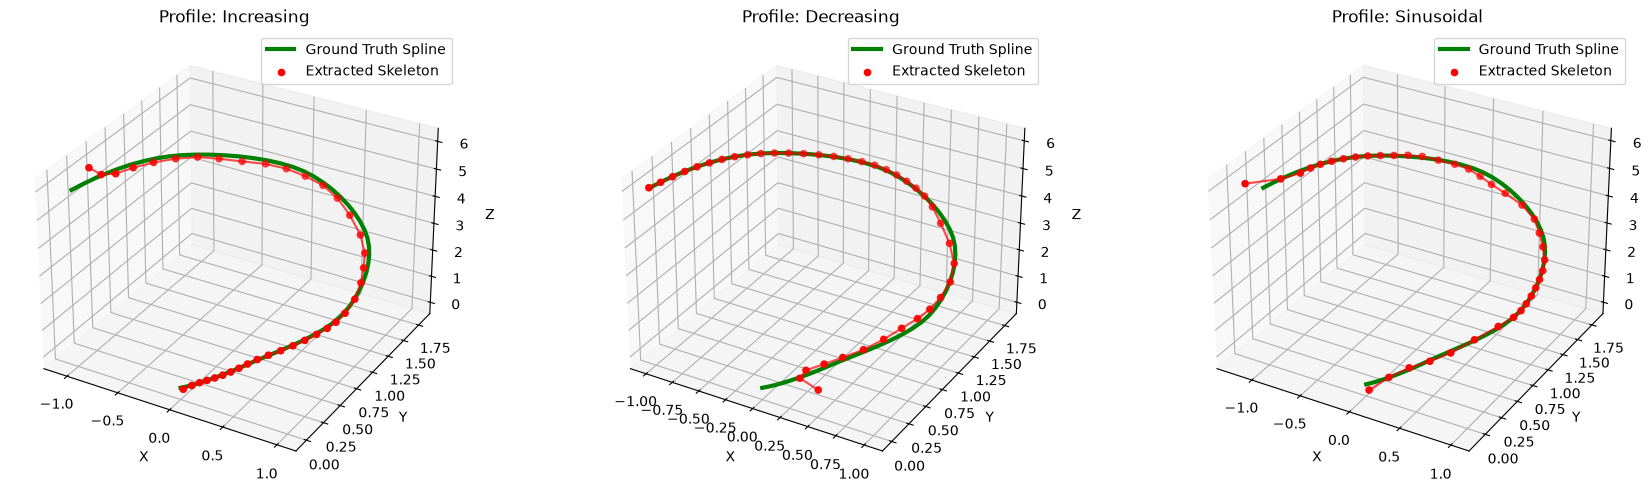

In [15]:
fig = plt.figure(figsize=(18, 5))

for idx, (profile_name, skel_data) in enumerate(extracted_skeletons.items()):
    ax = fig.add_subplot(1, 3, idx + 1, projection="3d")
    
    # Plot Ground Truth Spline
    ax.plot(curve_pts[:, 0], curve_pts[:, 1], curve_pts[:, 2], "g-", linewidth=3, label="Ground Truth Spline")
    
    # Plot Extracted Skeleton (Algo B + Taubin)
    v, e = skel_data["lap_t2"]
    ax.scatter(v[:, 0], v[:, 1], v[:, 2], c="r", s=20, label="Extracted Skeleton")
    for edge in e:
        p1, p2 = v[edge[0]], v[edge[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], "r-", alpha=0.7)
        
    ax.set_title(f"Profile: {profile_name.capitalize()}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()

plt.tight_layout()
plt.show()